In [ ]:
#PROJECT NAME :  Aerial Project.
# Contribution : Sidhant Badola

In [ ]:
#Github_Link :

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


In [ ]:
train_path = r"C:\Users\hp\Downloads\classification_dataset\train\train"
val_path = r"C:\Users\hp\Downloads\classification_dataset\valid\valid"
test_path = r"C:\Users\hp\Downloads\classification_dataset\test\test"

#Loaded all three data sets of training data, validation data and testing data.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalization process. The raw pixel values ranging 0 to 255. Here when divided by 255, it scales them to the value ranging 0 and 1. This helps the neural network to learn faster.
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)   # The rotation, zoom, horizontal flip are applied only to the training data and does not affect the original dataset. This is done to make the model not just memorize image
     # but to look at these through all angles and hence increasing the probability of detecting and classifying them.

val_datagen = ImageDataGenerator(rescale=1./255)
# here I have only rescale the validation dataset and not augmented it as I need to use to test it to real world images
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)
#  flow_from_directory fetches the data from computer folders. 224, 224 crops all images no matter the size to 224 224 pixel as it is the standard image size used in many models.

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'       # the binary tells us that we are doing classification of two objects "bird" vs "drone"
)


Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


In [ ]:
# A CNN model (convolutionary neural network) is trained by keras/tensor flow library to prepare images.
# It automates the process of loading images from folders, resizing them, and feeding them to the model in small batches.


In [ ]:
# MobileNetV2 is a family of Convolution neural network (CNN) architecture designed by Google, it has already seen millions of images and it knows how to recognize shape and texture of images.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,      # 'include_top = False' plays huge importance. The top of the model, this is the final layer of classification that decides if something is a Dog or Cat.
                             # By setting this to "False" I chop of the final layer, so I can add my own specific later on.
    weights='imagenet'
)     # By training on Inagenet, the knowledge gained by the model is being loaded. Here knowledge refers to 'weights'

base_model.trainable = False # this is used to freeze the pre-trained layers. It is not at all wide to chanfge the foundational patterns which MobileNet already knows.

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(), # it takes the complex 3d maps data coming out of MobileNet and flattens them to 1D vector.
    tf.keras.layers.Dense(1, activation='sigmoid') # This is the decision maker.  1: signifies "class_mode : binary" from previous codes.
    # A single number is the output. 'Sigmoid' : it squashes or smashes the value between 0 and 1 to binary values. number closer to 0 is given one class and the number closer to 1 s given another class.
])


In [ ]:
model.compile(
    optimizer='adam', # 'Adam' can be thought of as a nvigator or showing directions to the model as it adjust to how fast or slow the model learns.
    loss='binary_crossentropy', # It act as  a measure of how far our guess or prediction is from real like 0.8 is guess and 1.0 is the real one.
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5                     # It just means model will go through the dataset images 5 times.
)


C:\Users\hp\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.8452 - loss: 0.3364 - val_accuracy: 0.9548 - val_loss: 0.1614
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.9452 - loss: 0.1488 - val_accuracy: 0.9638 - val_loss: 0.1233
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.9594 - loss: 0.1172 - val_accuracy: 0.9683 - val_loss: 0.1108
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.9673 - loss: 0.0963 - val_accuracy: 0.9661 - val_loss: 0.1013
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.9737 - loss: 0.0811 - val_accuracy: 0.9683 - val_loss: 0.0917


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False   #
)


Found 215 images belonging to 2 classes.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions
y_pred = model.predict(test_data)
y_pred = (y_pred > 0.4).astype(int)  # Although the standard threshold is 0.5, I have taken it to be 0.4 as I had already tried with 0.5 and 0.4 causes the model  to able to detect one more drone images and the error in detection reduces to only 5 instead of 6.

# True labels
y_true = test_data.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))


7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step 
[[119   2]
 [  3  91]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       121
           1       0.98      0.97      0.97        94

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215



In [ ]:
import numpy as np

errors = np.where(y_pred.flatten() != y_true)[0]

print("Number of errors:", len(errors))


Number of errors: 5


In [ ]:
X_test = []
y_test = []

for i in range(len(test_data)):                      # test_data is a generator as it doesn't hold all data at once. First loop iterates through every batch in test_data.
    x_batch, y_batch = test_data[i]
    X_test.extend(x_batch)
    y_test.extend(y_batch)

X_test = np.array(X_test)
y_test = np.array(y_test)


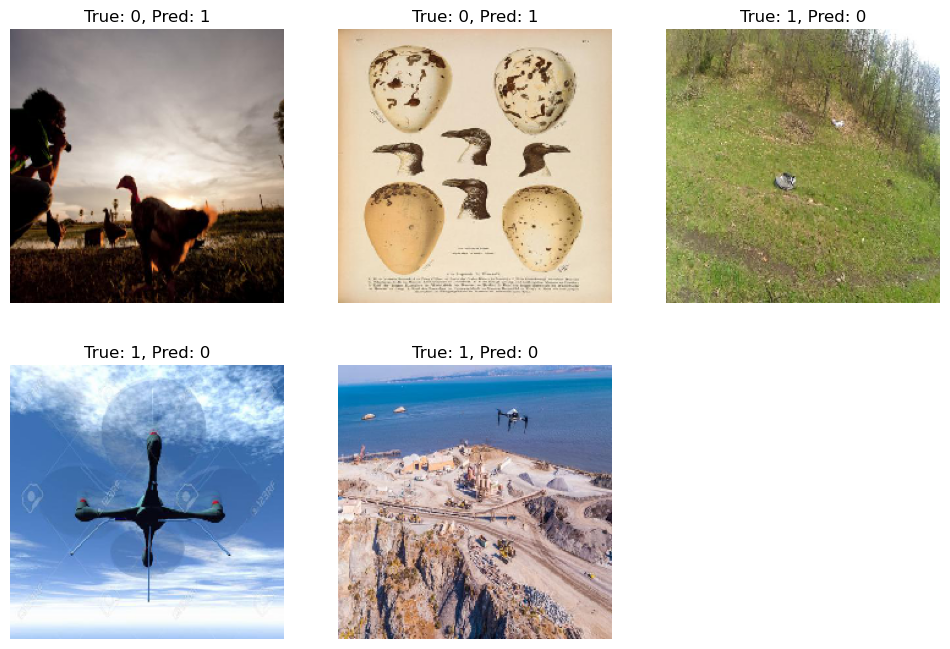

In [ ]:
import matplotlib.pyplot as plt

errors = np.where(y_pred.flatten() != y_true)[0]

plt.figure(figsize=(12,8))

for i, idx in enumerate(errors[:6]):  # indexing
    img = X_test[idx]
    true_label = y_test[idx]
    pred_label = y_pred[idx][0]

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"True: {int(true_label)}, Pred: {int(pred_label)}")
    plt.axis('off')

plt.show()


In [ ]:
#In the Images we observe that, 1st image is of Emu: A flightless bird, 2nd image is of eggs and bird.
#3rd image seems to be of GOAT but with shape of drone, 4th image is of a drone,
#5th image is of drone flying high in a desert area.

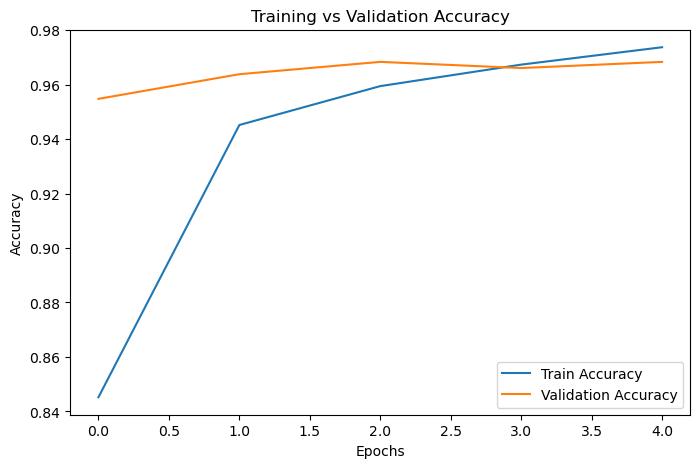

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


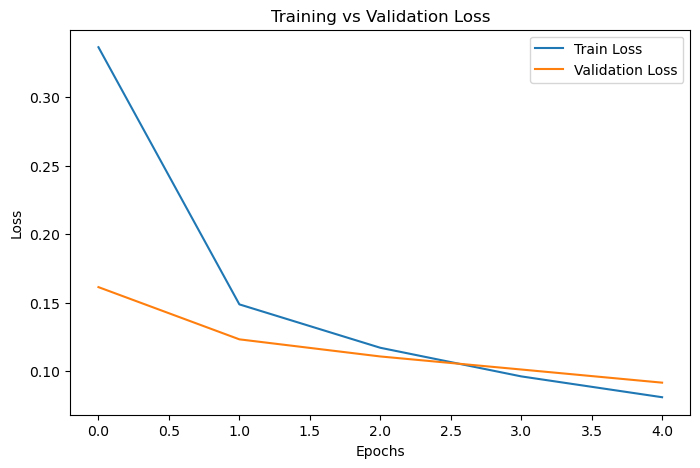

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
#The training and validation accuracy curves show consistent improvement and convergence, while the loss curves decrease steadily without divergence.
#This indicates that the model has learned meaningful features and generalizes well without overfitting.

In [ ]:
model.save("Aerial_Project_Bird_Drone.keras")

In [1]:
import torch
print(torch.cuda.is_available())


True


In [2]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.5 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [15]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
Dataset_Path = "/content/drive/MyDrive/object_detection_Dataset (1)"


In [19]:
import os
print(os.listdir(Dataset_Path))


['data.yaml', 'README.roboflow.txt', 'test', 'README.dataset.txt', 'valid', 'train']


In [21]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data = "/content/drive/MyDrive/object_detection_Dataset (1)/data.yaml",
    epochs = 50,
    imgsz = 640,
    batch = 16
)


Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/object_detection_Dataset (1)/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b0e55282540>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [22]:
model.predict(
    source=f"{Dataset_Path}/test/images",
    save=True
)



image 1/224 /content/drive/MyDrive/object_detection_Dataset (1)/test/images/00083b384685315d_jpg.rf.abfd1b2cc8c681777bae66d5327bb9ea.jpg: 640x640 1 Bird, 7.3ms
image 2/224 /content/drive/MyDrive/object_detection_Dataset (1)/test/images/00188d7f40a84793_jpg.rf.7f9da2b662dc236fbdcc1f22d8e0983e.jpg: 640x640 1 Bird, 14.1ms
image 3/224 /content/drive/MyDrive/object_detection_Dataset (1)/test/images/0028adf0e92c3da2_jpg.rf.48c97d30547a46e83abcbd1bf801c72f.jpg: 640x640 1 Bird, 27.9ms
image 4/224 /content/drive/MyDrive/object_detection_Dataset (1)/test/images/00347cbbeed4bedb_jpg.rf.aa19c9a7a22d76f8539ca12ac7cb82d5.jpg: 640x640 1 Bird, 7.3ms
image 5/224 /content/drive/MyDrive/object_detection_Dataset (1)/test/images/004cc8de466969bc_jpg.rf.ca1ffa31f30a92a3987e689583983973.jpg: 640x640 1 Bird, 7.2ms
image 6/224 /content/drive/MyDrive/object_detection_Dataset (1)/test/images/006ce62a72df4dd4_jpg.rf.8f8e7b6e9a26a01be91ea1b7dc4011d2.jpg: 640x640 1 Bird, 7.2ms
image 7/224 /content/drive/MyDrive/ob

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Bird', 1: 'drone'}
 obb: None
 orig_img: array([[[63, 40, 25],
         [63, 40, 25],
         [63, 40, 25],
         ...,
         [69, 44, 28],
         [69, 44, 28],
         [69, 44, 28]],
 
        [[63, 40, 25],
         [63, 40, 25],
         [63, 40, 25],
         ...,
         [69, 44, 28],
         [69, 44, 28],
         [69, 44, 28]],
 
        [[63, 40, 25],
         [63, 40, 25],
         [63, 40, 25],
         ...,
         [69, 44, 28],
         [69, 44, 28],
         [69, 44, 28]],
 
        ...,
 
        [[74, 48, 34],
         [74, 48, 34],
         [74, 48, 34],
         ...,
         [81, 55, 38],
         [81, 55, 38],
         [81, 55, 38]],
 
        [[74, 48, 34],
         [74, 48, 34],
         [74, 48, 34],
         ...,
         [81, 55, 38],
         [81, 55, 38],
         [81, 55, 38]],
 
        [[74, 48,

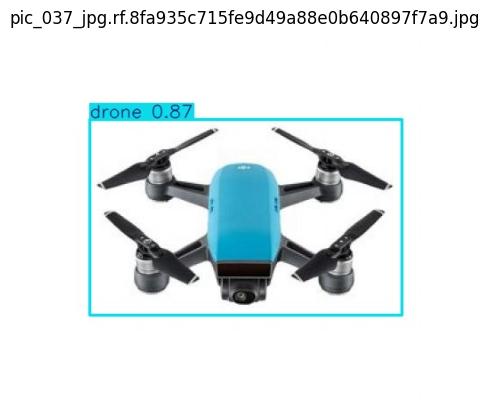

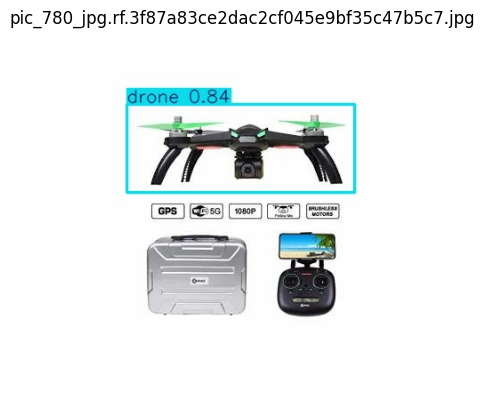

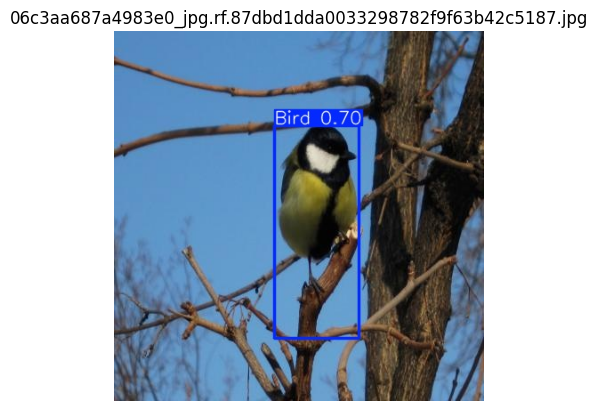

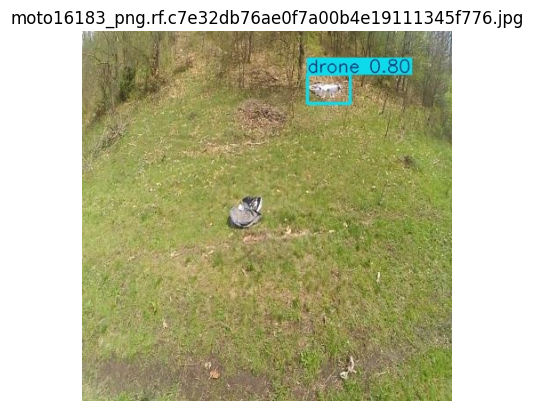

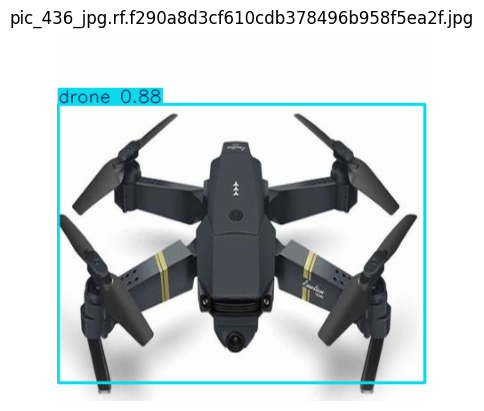

In [23]:
import matplotlib.pyplot as plt
import cv2
import os

pred_path = "runs/detect/predict"

for img in os.listdir(pred_path)[:5]:
    img_path = os.path.join(pred_path, img)
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(image)
    plt.title(img)
    plt.axis('off')
    plt.show()
